In [1]:
import dasly
from dasly.fitting.hyperbola_fitter import (
    fit_multiple_hyperbolas_least_squares,
    derive_hyperbola_metrics,
)
from dasly.execution.box_saver import build_box_df
from dasly.loader.fsearcher import parse_file_path


# Parameters


In [2]:
file_paths = [
    '../data/svalbard/20220822/dphi/122539.hdf5',
    '../data/svalbard/20220822/dphi/122549.hdf5',
    '../data/svalbard/20220822/dphi/122559.hdf5',
]

s_start, s_end = 5_000, 115_000  # Start and end channel indices
f_min, f_max = 15, 25  # Hz
v_min, v_max = 1_484, 1_4844  # m/s
rms_window_size = 0.5  # Window size for RMS calculation in seconds
new_size = (640, 640)  # New size for resizing (width, height)
binary_quantile = 0.95  # Quantile for binary transformation
binary_by_channel = True  # Apply binary transformation by channel
dbscan_points_eps = 1.25  # DBSCAN epsilon in seconds
dbscan_points_min_samples = 100  # Min samples for DBSCAN
dbscan_points_target_velocity = 1_750  # m/s
hyperbolas_num_points = 10  # Number of binary transformed points preserved
hyperbolas_by_channel = True  # Binary transformed points by channel


# Detection


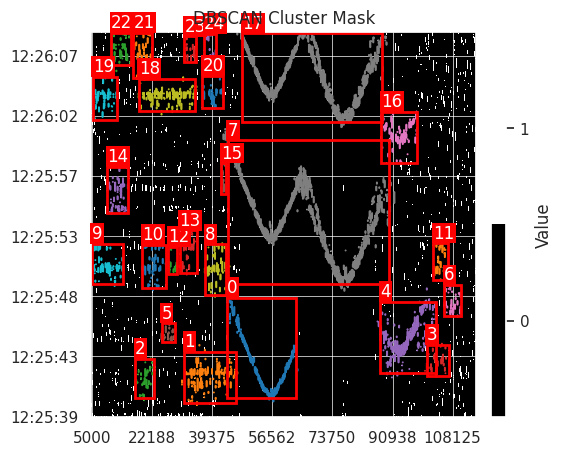

In [3]:
das_rms = (
    dasly.DASArray()
    .load(file_paths=file_paths, s_start=s_start, s_end=s_end)
    .fk_filter_real(f_min=f_min, f_max=f_max, v_min=v_min, v_max=v_max)
    .rms(window_size_second=rms_window_size)
)

das = (
    das_rms
    .resize_cv2(new_size=new_size)
    .binary_transform(
        quantile=binary_quantile,
        by_channel=binary_by_channel
    )
    .dbscan_points(
        eps=dbscan_points_eps / (len(file_paths) * 10 / new_size[1]),
        min_samples=dbscan_points_min_samples,
        target_velocity=dbscan_points_target_velocity
    )
)

fig, ax = das.plot(
    figsize=(5, 5),
    title='DBSCAN Cluster Mask',
    xlabel='',
    ylabel='',
    clusters=das.meta.cluster_labels,
    clusters_legend=False,
)

dasly.add_boxes(fig, das.meta.boxesn, num_boxes=True)


# Detection Boxes Information


In [4]:
hyperbolas = fit_multiple_hyperbolas_least_squares(
    array=das_rms,
    boxesn=das.meta.boxesn,
    num_points=hyperbolas_num_points,
    by_channel=hyperbolas_by_channel
)

hyper_metrics = derive_hyperbola_metrics(
    hyperbolas=hyperbolas,
    ds=das_rms.meta.ds,
    dx=das_rms.meta.dx
)

exp_path, yyyymmdd, hhmmss, hhmmss_hdf5 = parse_file_path(file_paths[0])
chunk = f'{yyyymmdd}T{hhmmss}'
additional = {
    'source_distance': hyper_metrics['source_distance'],
    'hyper_rmse_norm': hyper_metrics['hyper_rmse_norm'],
    'hyper_mae_norm': hyper_metrics['hyper_mae_norm'],
    'dbscan_size': das.meta.cluster_sizes
}

boxes_df = build_box_df(
    boxesp=das.meta.boxesp,
    boxesn=das.meta.boxesn,
    chunk=chunk,
    chunk_size=len(file_paths),
    additional=additional
)

boxes_df


,s1,t1,s2,t2,x1n,y1n,x2n,y2n,chunk,chunk_size,source_distance,hyper_rmse_norm,hyper_mae_norm,dbscan_size
0,43611.450195,2022-08-22 12:25:40.450854540+00:00,63174.584961,2022-08-22 12:25:48.219946384+00:00,0.351562,0.048438,0.529687,0.307812,20220822T122539,3,163.476300,0.145155,0.087741,906
1,31290.107422,2022-08-22 12:25:40.059591770+00:00,46013.940430,2022-08-22 12:25:44.024636745+00:00,0.239375,0.035375,0.373437,0.167750,20220822T122539,3,351346.914759,0.259486,0.216736,565
2,17355.664062,2022-08-22 12:25:40.425581455+00:00,22847.070312,2022-08-22 12:25:43.471439838+00:00,0.112500,0.047594,0.162500,0.149281,20220822T122539,3,9.764292,0.278203,0.234016,147
3,100584.790039,2022-08-22 12:25:42.173627138+00:00,106934.228516,2022-08-22 12:25:44.578301430+00:00,0.870313,0.105953,0.928125,0.186234,20220822T122539,3,26.206249,0.293150,0.248147,182
4,87371.093750,2022-08-22 12:25:42.370194674+00:00,103158.886719,2022-08-22 12:25:47.938667774+00:00,0.750000,0.112516,0.893750,0.298422,20220822T122539,3,0.194319,0.241075,0.189717,1002
5,24906.347656,2022-08-22 12:25:44.805757999+00:00,28853.295898,2022-08-22 12:25:46.251932382+00:00,0.181250,0.193828,0.217188,0.242109,20220822T122539,3,5.527615,0.260627,0.218823,106
6,105561.376953,2022-08-22 12:25:46.837890387+00:00,110285.702393,2022-08-22 12:25:49.227588177+00:00,0.915625,0.261672,0.958641,0.341453,20220822T122539,3,0.002255,0.292746,0.251710,148
7,43783.056641,2022-08-22 12:25:49.296386719+00:00,89773.583984,2022-08-22 12:26:00.482006788+00:00,0.353125,0.343750,0.771875,0.717187,20220822T122539,3,0.000732,0.185486,0.153557,3941
8,37262.011719,2022-08-22 12:25:48.449743032+00:00,43268.237305,2022-08-22 12:25:52.389514923+00:00,0.293750,0.315484,0.348438,0.447016,20220822T122539,3,0.177234,0.296043,0.254443,292
9,5000.000000,2022-08-22 12:25:49.303406954+00:00,13923.535156,2022-08-22 12:25:52.425084114+00:00,0.000000,0.343984,0.081250,0.448203,20220822T122539,3,0.096411,0.272779,0.213774,316
